# Modelado Jerárquico

In [1]:
# ==========================
# Entorno estable para PyMC + PreliZ en Colab
# ==========================

!pip uninstall -y \
    preliz \
    pytensor \
    pytensor-distributions \
    arviz_stats \
    numba \
    llvmlite

!pip install -U --no-cache-dir \
    "numpy==2.0.2" \
    "scipy==1.16.1" \
    "pandas==2.3.0" \
    "matplotlib==3.10.0" \
    "llvmlite==0.43.0" \
    "numba==0.60.0" \
    "arviz==0.22.0" \
    "pymc==5.28.5" \
    "pytensor==2.38.3" \
    "arviz_stats==0.6.0" \
    "preliz==0.20.0"

print("\n==============================")
print("IMPORTANTE")
print("Ahora hacé Runtime > Restart session")
print("y recién después ejecutá las celdas del notebook.")
print("==============================")

Found existing installation: pytensor 2.38.3
Uninstalling pytensor-2.38.3:
  Successfully uninstalled pytensor-2.38.3
Found existing installation: numba 0.60.0
Uninstalling numba-0.60.0:
  Successfully uninstalled numba-0.60.0
Found existing installation: llvmlite 0.43.0
Uninstalling llvmlite-0.43.0:
  Successfully uninstalled llvmlite-0.43.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 74.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 215.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 78.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 127.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.9/43.9 MB 122.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 94.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 271.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.8/108.8 kB 309.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━

In [2]:
import arviz as az
import pymc as pm
import preliz as pz

import numpy as np
import scipy.stats as stats
import pandas as pd
import matplotlib.pyplot as plt

az.style.use("arviz-doc")

/usr/local/lib/python3.12/dist-packages/preliz/ppls/pymc_io.py:12: FutureWarning: `pytensor.graph.basic.ancestors` was moved to `pytensor.graph.traversal.ancestors`. Calling it from the old location will fail in a future release.
  from pytensor.graph.basic import ancestors


In [3]:
#| code-fold: true

az.style.use('arviz-doc')

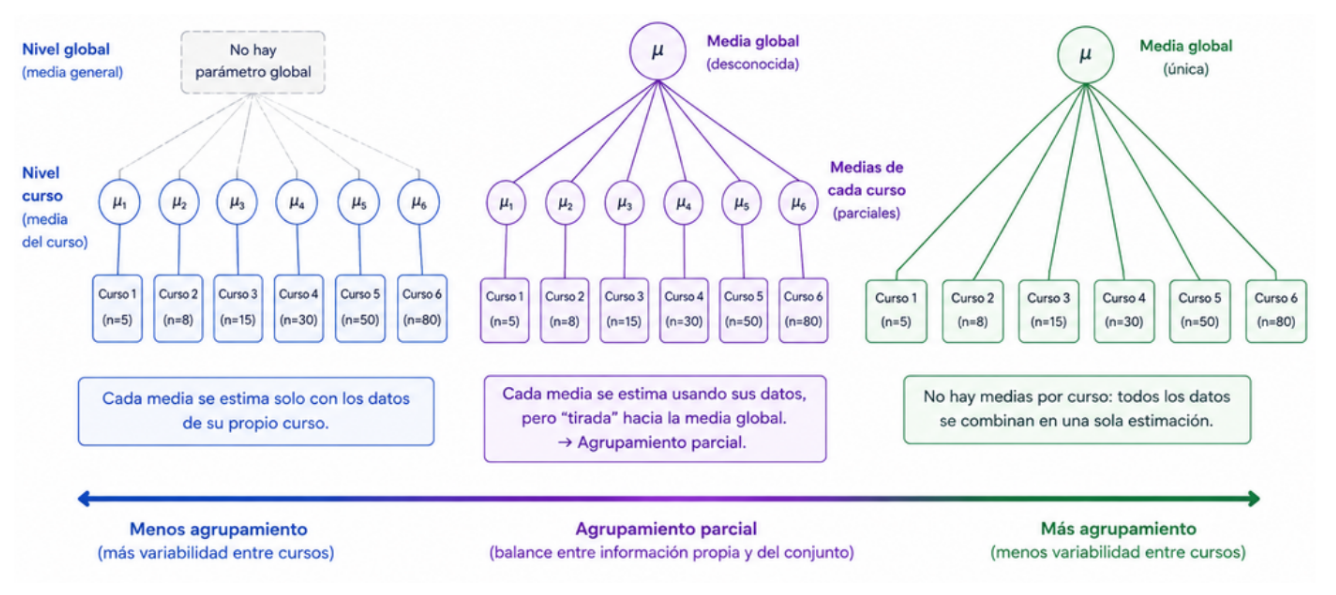

# **Ejemplo para resolver en clase (se encuentra en el TP 3):**

Una empresa agrícola desea evaluar la calidad de un nuevo tratamiento para semillas. Para ello, se sembraron semillas tratadas en distintos invernaderos. En cada uno se registró si cada semilla logró germinar correctamente.

Cada observación se codifica como:

* 1: la semilla germinó correctamente.

* 0: la semilla no germinó.

Los datos se encuentran agrupados por invernadero. Aunque cada invernadero puede presentar condiciones particulares de temperatura, humedad o iluminación, se supone que todos pertenecen a una misma población y, por lo tanto, resulta razonable modelarlos mediante un enfoque jerárquico.

Para este ejercicio se utilizarán datos sintéticos correspondientes a cuatro invernaderos.

In [4]:

# Cantidad de semillas evaluadas por invernadero
N = [20, 30, 25, 40]

# Cantidad de semillas germinadas
G = [15, 18, 11, 34]

group_idx = np.repeat(np.arange(len(N)), N)

data = []

for i in range(len(N)):
    data.extend(np.repeat([1, 0], [G[i], N[i]-G[i]]))

data = np.array(data)

Actividades:

a) Plantee un modelo jerárquico bayesiano para estimar la probabilidad de germinación de cada invernadero. Describa el significado de cada uno de los parámetros e indique qué distribución asignaría a cada nivel del modelo.

b) Implemente el modelo utilizando PyMC y obtenga muestras de la distribución posterior.

c) Obtenga un resumen posterior de las probabilidades de germinación de cada invernadero y de los hiperparámetros del modelo. ¿Qué información aporta cada uno de ellos?

d) Repita el análisis modificando únicamente los datos del último invernadero para obtener los siguientes escenarios

In [5]:
# Escenario A
G = [15, 18, 11, 34]

In [6]:
# Escenario B
G = [15, 18, 11, 8]

In [7]:
# Escenario C
G = [15, 18, 11, 20]

Compare las estimaciones obtenidas para los tres escenarios y explique cómo influye la información proveniente de los demás invernaderos sobre la estimación del último grupo.

e) A partir de los resultados obtenidos, responda:

¿En qué situaciones el modelo jerárquico produce una mayor contracción (shrinkage)?

¿Qué ventajas presenta este enfoque frente a estimar cada invernadero de manera independiente?

¿En qué circunstancias dejaría de ser razonable asumir que los invernaderos son intercambiables?

Resolución:

In [ ]:
#def logistic(x):
 #   return 1 / (1 + np.exp(-x))

Tenemos cuatro invernaderos. En cada uno observamos una cantidad de semillas y cuántas germinaron:

| Invernadero | Semillas (N_i) | Germinadas (G_i) | Proporción observada |
| ----------- | -------------: | ---------------: | -------------------: |
| 1           |             20 |               15 |                 0.75 |
| 2           |             30 |               18 |                 0.60 |
| 3           |             25 |               11 |                 0.44 |
| 4           |             40 |               34 |                 0.85 |


La idea es que cada invernadero puede tener su propia probabilidad de germinación, pero esas probabilidades no son completamente independientes: suponemos que los cuatro invernaderos pertenecen a una misma población.

**a) Planteamiento del modelo jerárquico**

**Nivel 1: datos**

Para cada invernadero $i=1,…,4,$ tenemos $N_i$ semillas y $G_i$ germinaciones.

Por lo tanto:

$$G_i​∼Binomial(N_i​,p_i​)$$

donde:

* $G_i:$ cantidad de semillas que germinaron;
* $N_i:$ cantidad total de semillas evaluadas;
* $p_i:$ probabilidad de germinación del invernadero $i$.

Por ejemplo, para el invernadero 1: $G_1​∼Binomial(20,p_1​)$

**Nivel 2: probabilidades de los invernaderos**

El problema es que $p_i$ debe estar entre 0 y 1. Por eso trabajamos con la escala logística:

$$logit(p_i​)=α_i​$$

o equivalentemente:

$$p_i​=logit^{−1}(α_i​)=\frac{1}{1+e^{−α_i}}​.$$

Ahora podemos modelar los efectos de cada invernadero:

$$α_i∼N(μ,σ)$$

Esta es la parte jerárquica.

La interpretación es:

* $α_i:$ efecto particular del invernadero $i$;

* $μ:$ efecto promedio de la población de invernaderos;

* $σ:$ cuánto varían los invernaderos alrededor de ese promedio.

En otras palabras, no suponemos que los cuatro invernaderos tienen exactamente la misma probabilidad de germinación, pero sí suponemos que sus efectos provienen de una distribución común.

**Nivel 3: hiperparámetros**

Necesitamos asignar priors a $μ$ y $σ$.

Una elección razonable es:

$$μ∼N(0,2)$$

y

$$σ∼HalfNormal(2)$$

Entonces tenemos el siguiente resumen:

$$G_i∼ Binomial(N_i,p_i)$$
$$p_i∼logit^{-1}(α_i)$$
$$α_i∼N(\mu,σ)$$
$$μ∼N(0,2)$$
$$σ∼HalfNormal(2)$$

con $i=1,…,4$.

***¿Por qué este modelo es jerárquico?:***

Porque tenemos distintos niveles:

Nivel de observación

$$G_i∣p_i$$

Luego, a nivel grupal o por invernadero
	​
$$α_i​∣μ,σ$$

y por último un "nivel poblacional"

$$μ,σ$$

Observación: Los invernaderos comparten información a través de $μ$ y $σ$, evitando que cada invernadero sea tratado como un problema completamente independiente.

b) **Construyamos le modelo:**

In [8]:
N = np.array([20, 30, 25, 40])
G = np.array([15, 18, 11, 34])

In [9]:
with pm.Model() as modelo:

    # Hiperparámetros
    mu = pm.Normal("mu", mu=0, sigma=2)
    sigma = pm.HalfNormal("sigma", sigma=2)

    # Efectos de cada invernadero
    alpha = pm.Normal(
        "alpha",
        mu=mu,
        sigma=sigma,
        shape=4
    )

    # Probabilidad de germinación
    p = pm.Deterministic(
        "p",
        pm.math.sigmoid(alpha)  # ¡observen que es la misma que definí a mano arriba de todo!
    )

    # Datos observados
    germinadas = pm.Binomial(
        "germinadas",
        n=N,
        p=p,
        observed=G
    )

Generamos las muestras:

In [10]:
with modelo:
    idata = pm.sample(
        2000,
        tune=2000,
        chains=4,
        target_accept=0.95,
        random_seed=123
    )

Output()

ERROR:pymc.stats.convergence:There were 49 divergences after tuning. Increase `target_accept` or reparameterize.


¿Por qué `target_accept=0.95`?

Porque en modelos jerárquicos puede ser más frecuente encontrar problemas de geometría posterior y divergencias.

Aumentar `target_accept` hace que NUTS utilice pasos más pequeños y puede ayudar a reducirlas.

Pero atención: no significa que poner `target_accept=0.95` haga que cualquier divergencia desaparezca mágicamente. Las divergencias son un diagnóstico que debemos revisar.

Hacemos un resumen de datos de la smuestras generadas:

In [11]:
az.summary(
    idata,
    var_names=["mu", "sigma", "p", "alpha"],
    round_to=3
)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu,0.702,0.607,-0.501,1.895,0.010,0.011,4141.680,3774.340,1.002
sigma,1.094,0.618,0.124,2.206,0.011,0.010,1400.425,593.866,1.003
p[0],0.729,0.087,0.563,0.888,0.001,0.001,6733.002,5052.573,1.001
p[1],0.613,0.082,0.458,0.763,0.001,0.001,6745.635,5975.555,1.000
p[2],0.485,0.098,0.306,0.667,0.002,0.001,4129.321,3064.538,1.001
p[3],0.818,0.063,0.703,0.931,0.001,0.001,3677.050,812.072,1.001
alpha[0],1.041,0.471,0.167,1.928,0.006,0.006,6733.002,5052.573,1.001
alpha[1],0.474,0.355,-0.191,1.141,0.004,0.004,6745.635,5975.555,1.000
alpha[2],-0.061,0.408,-0.809,0.708,0.006,0.005,4129.321,3064.538,1.001
alpha[3],1.560,0.441,0.739,2.358,0.007,0.005,3677.050,812.072,1.001


/tmp/ipykernel_1571/2757621767.py:5: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


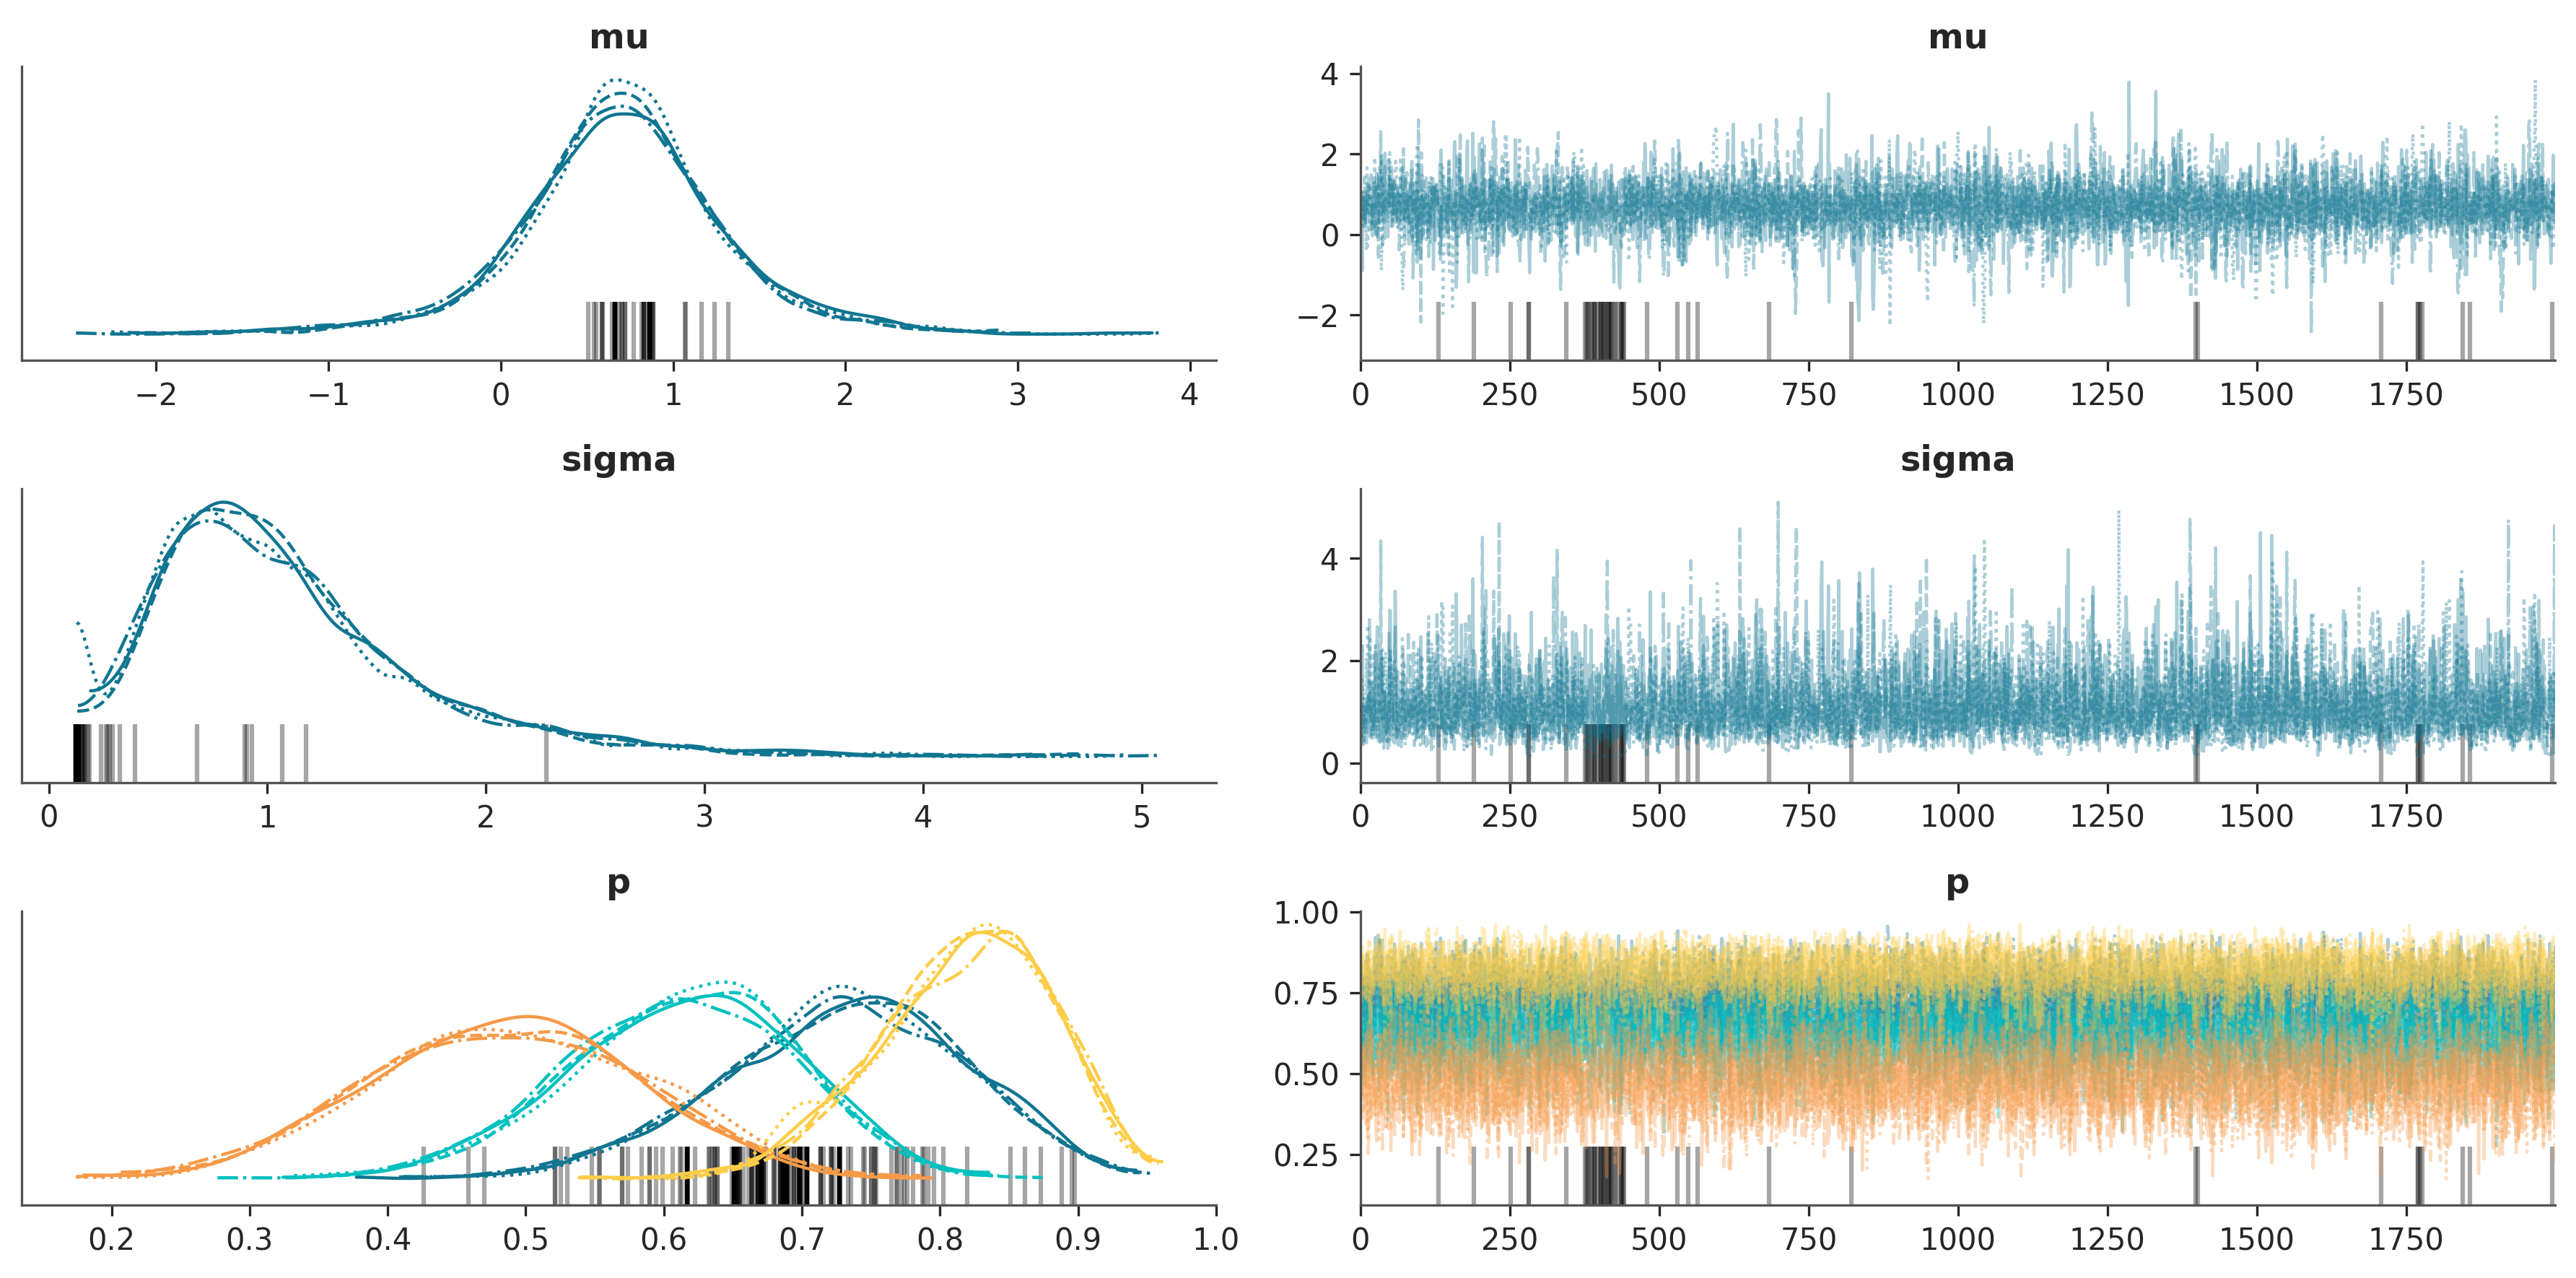

In [12]:
az.plot_trace(
    idata,
    var_names=["mu", "sigma", "p"]
)
plt.tight_layout()

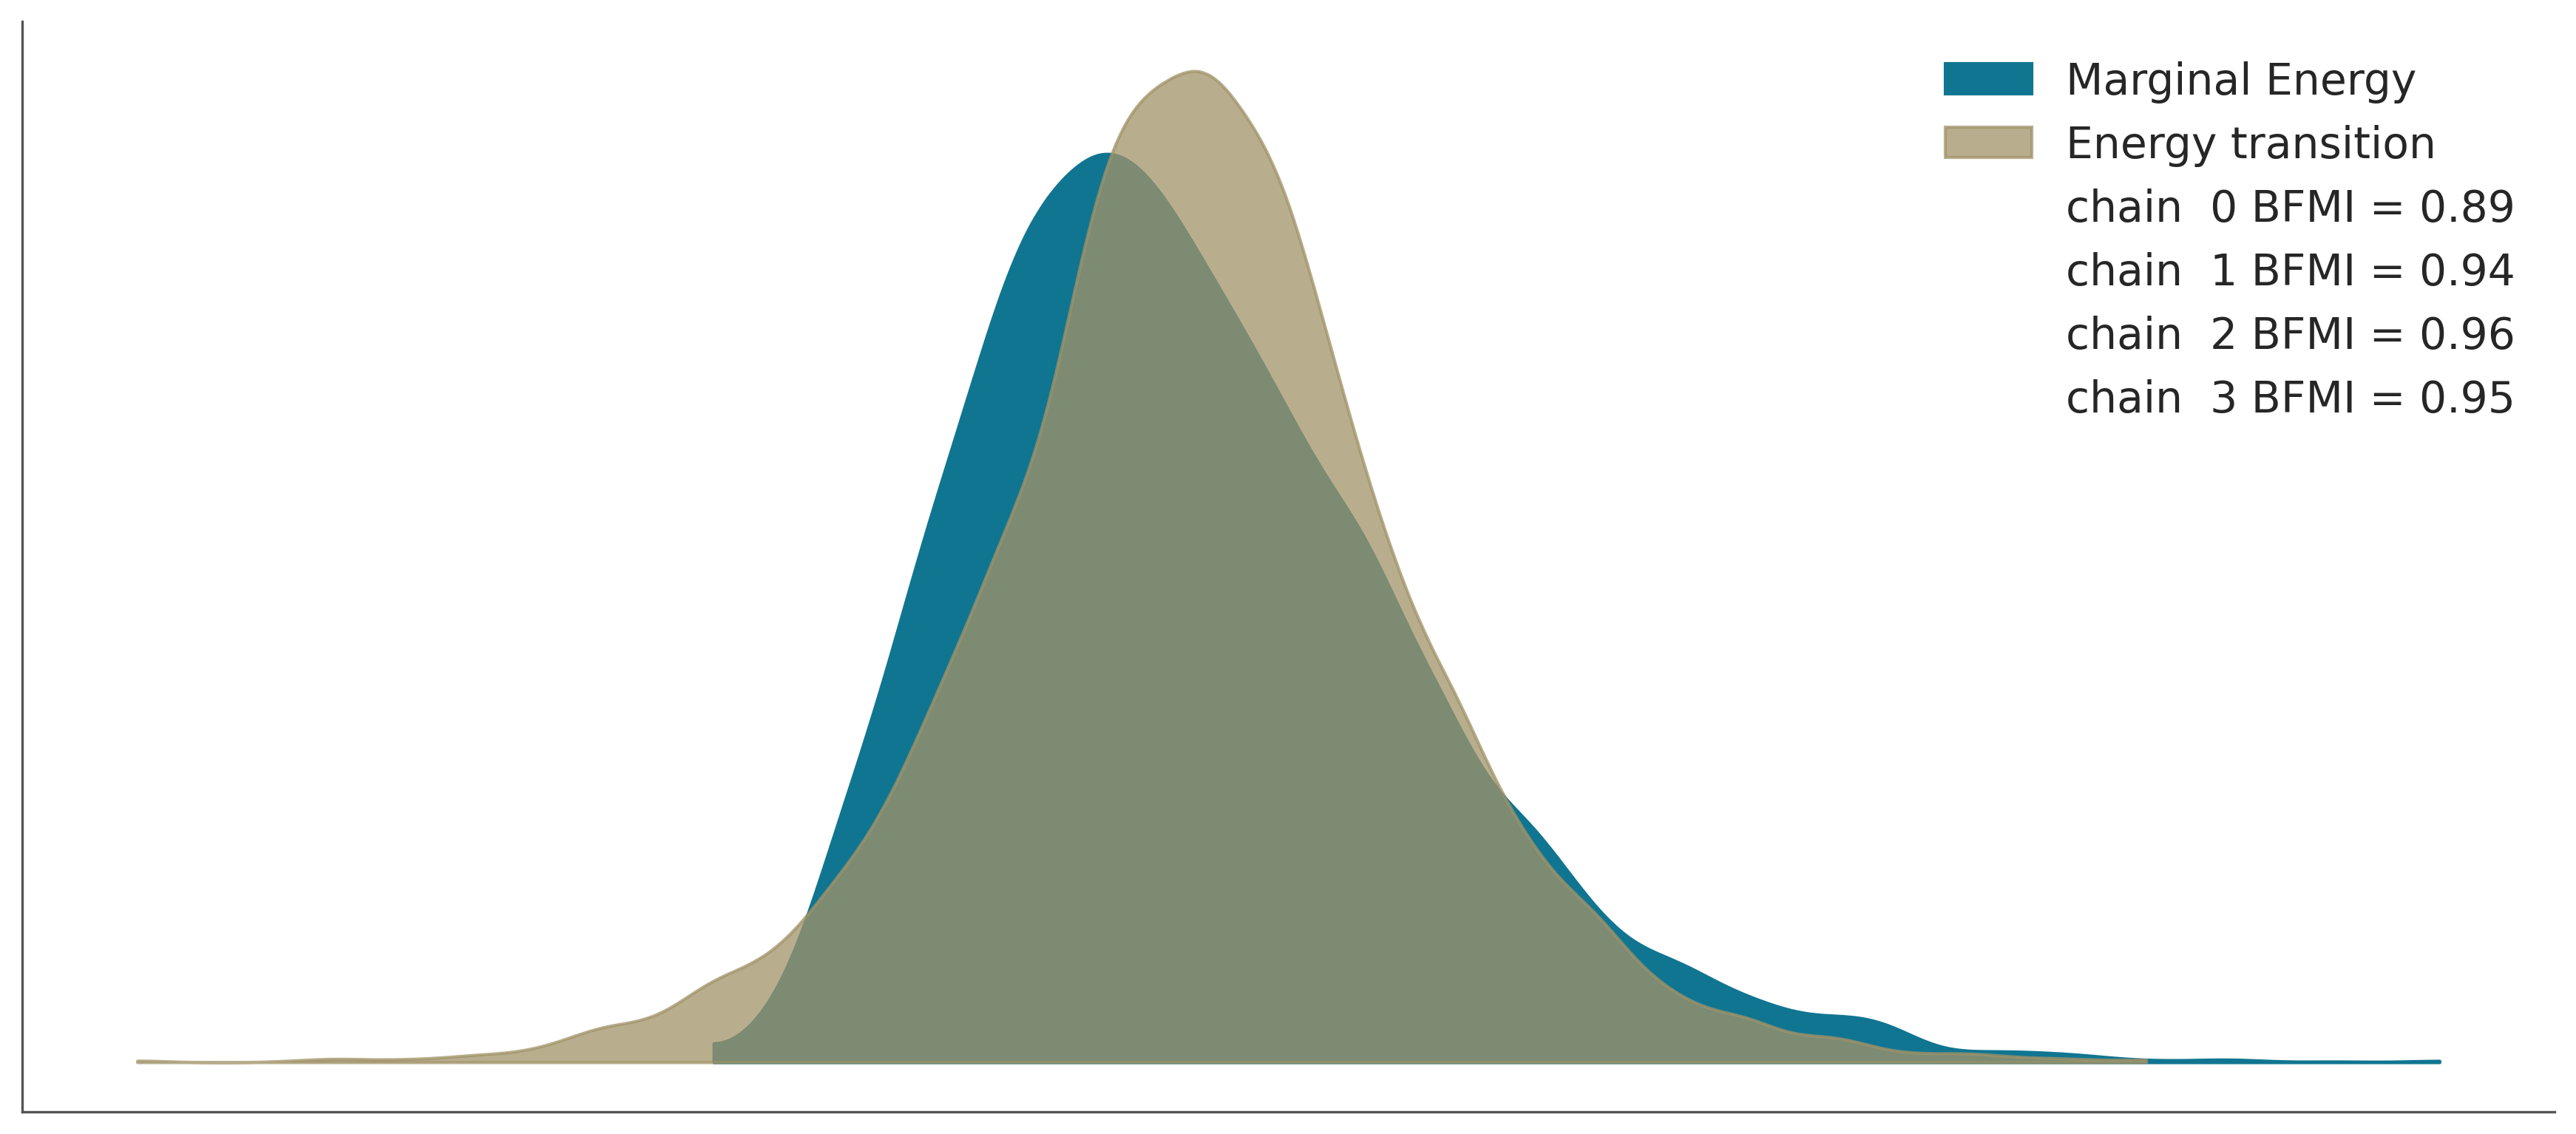

In [13]:
az.plot_energy(idata)
plt.show()

Y trabajamos con un breve análisis de divergencias:

In [14]:
divergencias = idata.sample_stats["diverging"].sum().item()

print("Número de divergencias:", divergencias)

Número de divergencias: 49


**¿Qué hacemos si aparecen divergencias?** Si bien en este ejemplo no vamos a tratar con demasiada profundidad, podemos hacer un esquema de cómo intentar reducir las divergencias del modelo.

Si obtenemos, por ejemplo:

*`There were X divergences after tuning.`*

no deberíamos simplemente ignorarlas.

Las divergencias indican que NUTS tuvo dificultades para explorar correctamente alguna región de la distribución posterior.

Podemos intentar cambiar `target_accept`:

In [ ]:
#target_accept=0.95

In [ ]:
#target_accept=0.99

por ejemplo:

In [15]:
with modelo:
    idata = pm.sample(
        2000,
        tune=3000,
        chains=4,
        target_accept=0.99,
        random_seed=123
    )

Output()

ERROR:pymc.stats.convergence:There were 22 divergences after tuning. Increase `target_accept` or reparameterize.


imprimimos las divergencias:

In [16]:
idata.sample_stats["diverging"].sum().item()

22

Observen queiInicialmente se observaron algunas divergencias durante el muestreo. Se aumentó target_accept para utilizar pasos de muestreo más conservadores. Luego de volver a ajustar el modelo, las divergencias disminuyeron, por lo que se continuará con la segunda muestra. Como no desaparecieron por completo, las estimaciones deben interpretarse con cautela dado que los posibles problemas de exploración de la distribución posterior y no deberían ignorarse como si fueran simplemente ruido computacional.


c) Resumen posterior

In [17]:
az.summary(
    idata,
    var_names=["p", "mu", "sigma"],
    hdi_prob=0.94,
    round_to=3
)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
p[0],0.727,0.089,0.562,0.891,0.001,0.001,4945.356,4553.044,1.001
p[1],0.614,0.083,0.452,0.760,0.001,0.001,5099.730,4871.377,1.001
p[2],0.488,0.100,0.313,0.686,0.002,0.001,3480.932,1471.753,1.001
p[3],0.817,0.062,0.698,0.927,0.001,0.001,4047.432,2196.492,1.002
mu,0.683,0.605,-0.446,1.848,0.010,0.012,4227.556,3897.463,1.001
sigma,1.094,0.613,0.074,2.172,0.011,0.011,2272.192,1111.989,1.004


**Probabilidades $p_i$:**
	​
  
Tenemos:

$$p_1 ,p_2,p_3,p_4$$

que representan las probabilidades de germinación estimadas para cada invernadero.

No debemos confundirlas con las proporciones observadas.

Las proporciones observadas son:

$$(0.75,0.60,0.44,0.85)$$

Las probabilidades posteriores $p_i$ incorporan tanto los datos del propio invernadero como la información proveniente de los otros invernaderos.


$\mu:$

representa el centro de la distribución de los efectos $α_i.$

Como $μ$ está en escala logística, para interpretarlo en términos de probabilidad podemos transformar, después de extraer muestras:

In [18]:
mu_post = idata.posterior["mu"]

mu_prob = 1 / (1 + np.exp(-mu_post))

Así obtenemos una medida del nivel poblacional de germinación.

$σ:$

mide la variabilidad entre los invernaderos.

Una interpretación sencilla:

* $σ$ pequeña → los invernaderos tienden a ser parecidos;
* $σ$ grande → hay mayor heterogeneidad entre invernaderos.

Por eso $σ$ es fundamental para entender cuánto pooling o contracción esperamos.

Podemos comparar las proporciones observadas con las estimaciones posteriores:

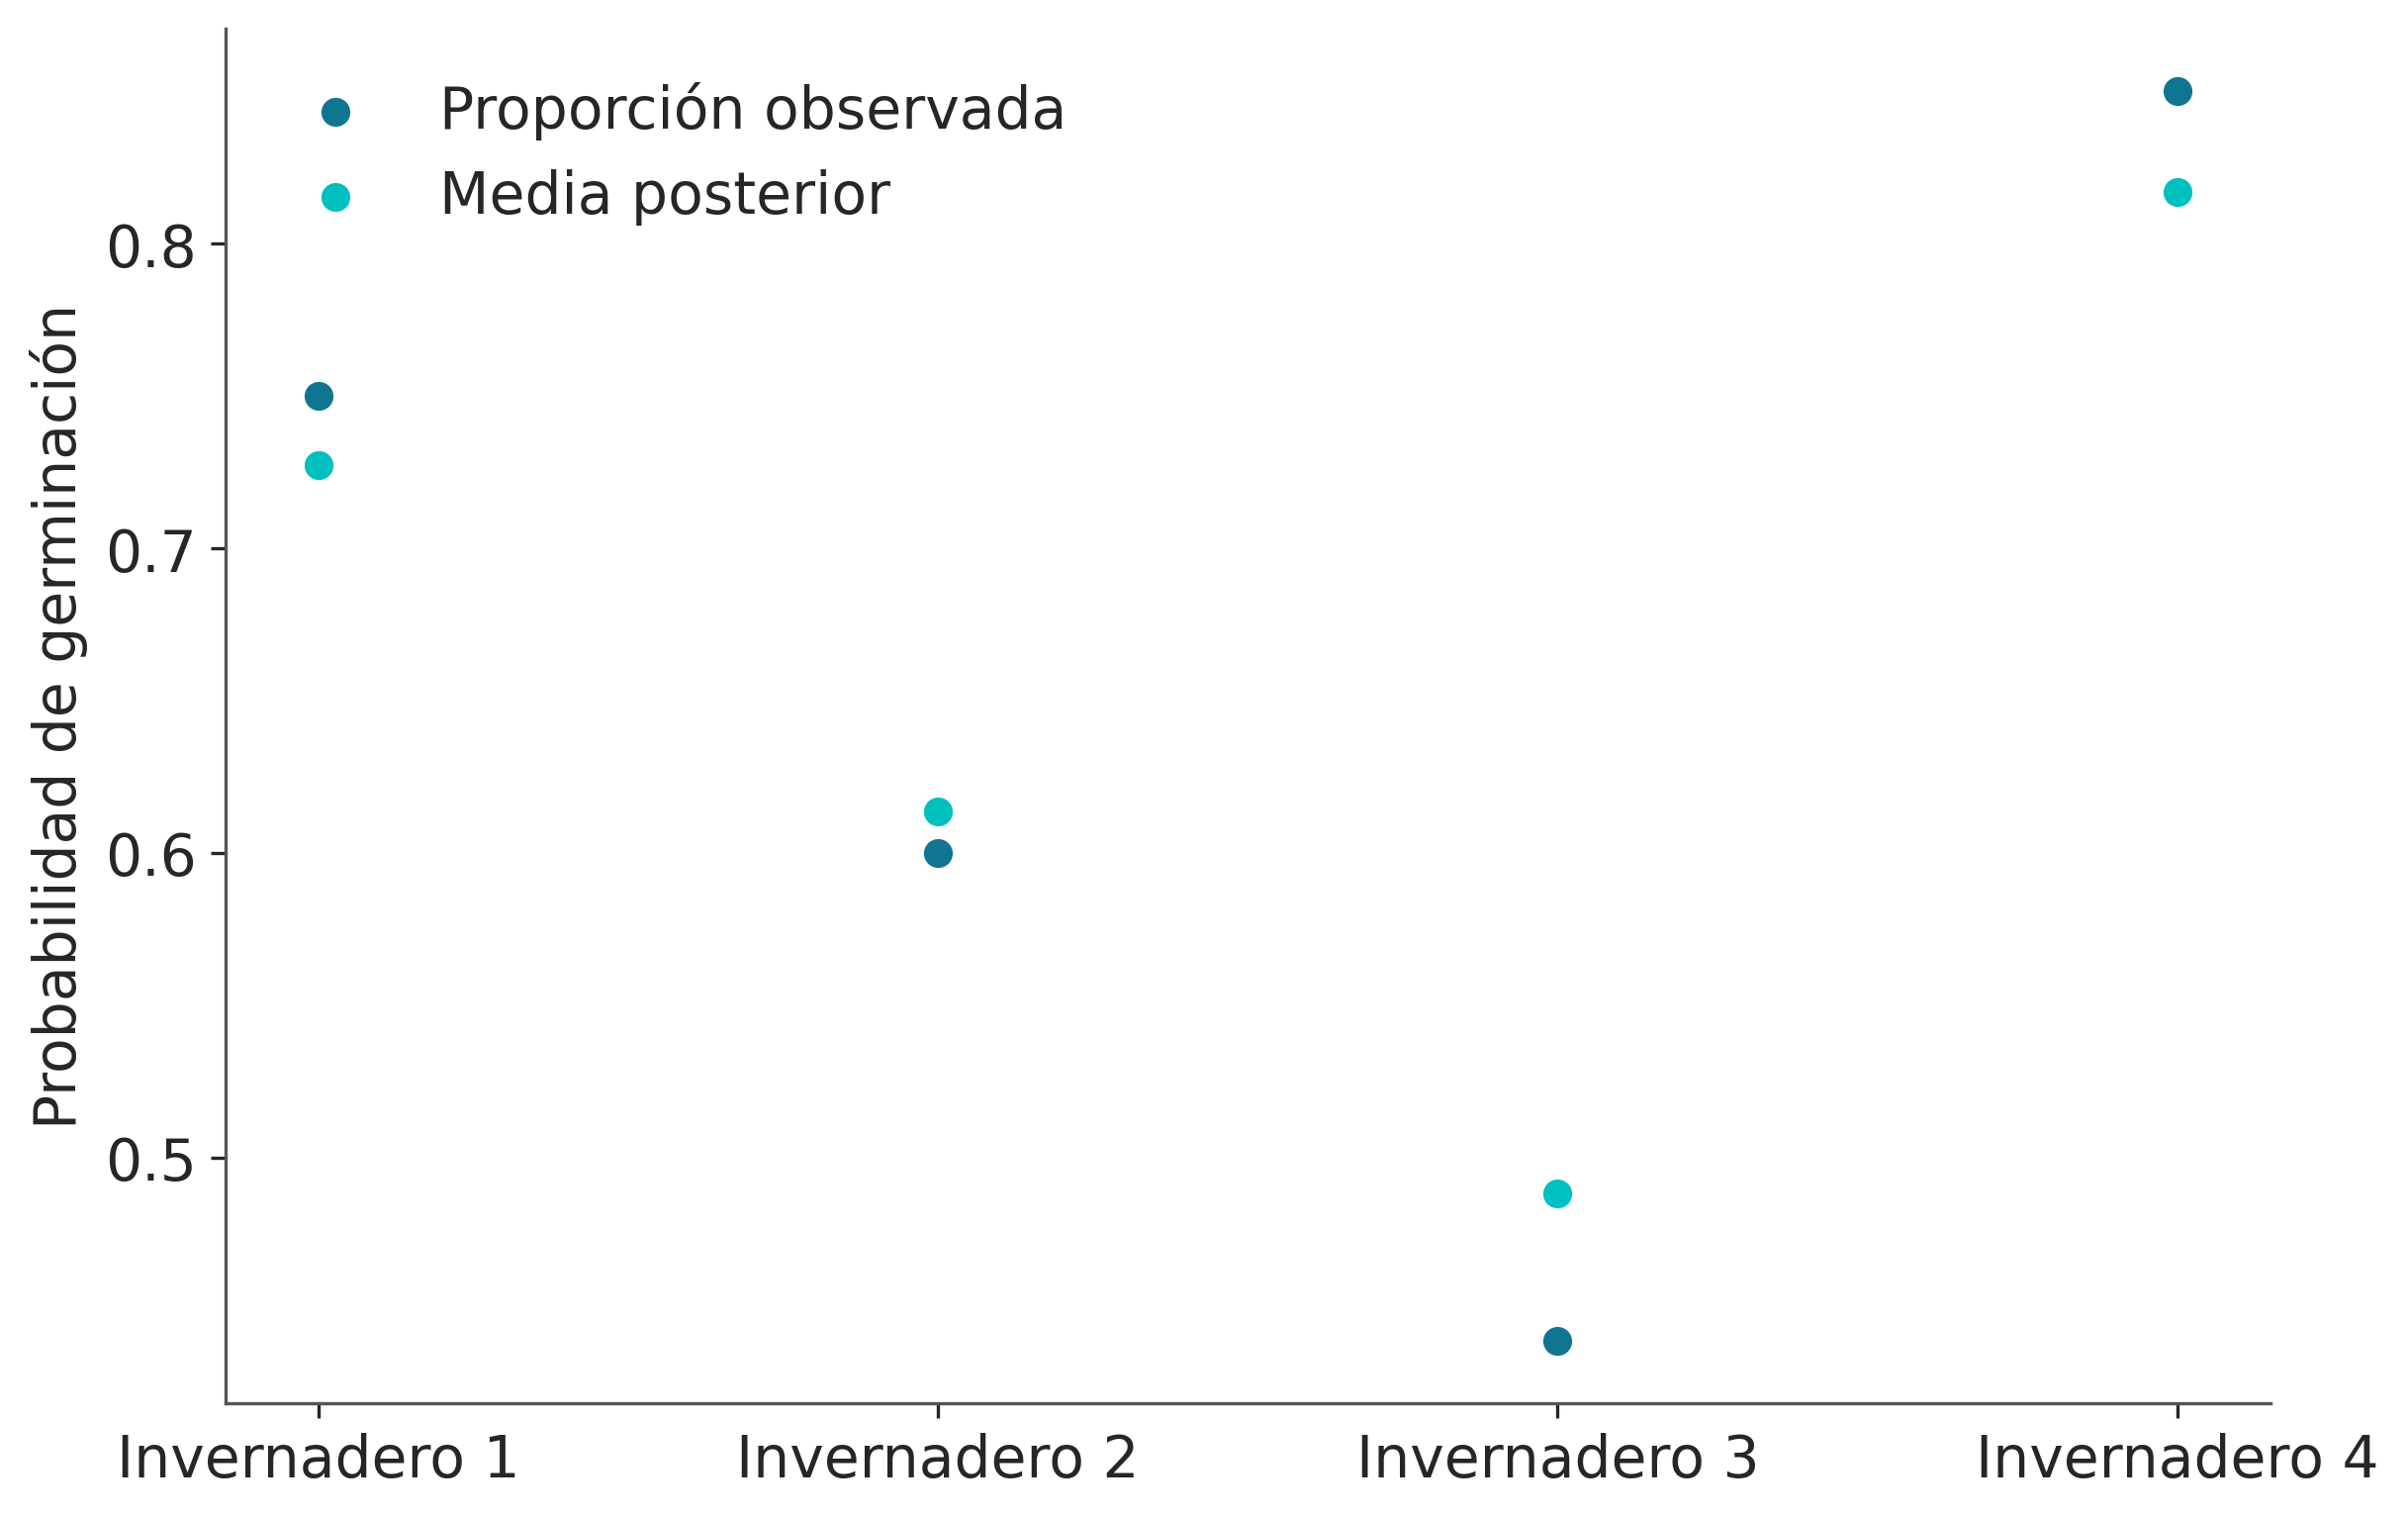

In [19]:
post = az.extract(idata)

p_mean = post["p"].mean("sample")

plt.figure(figsize=(8,5))

plt.scatter(
    np.arange(4),
    G / N,
    label="Proporción observada"
)

plt.scatter(
    np.arange(4),
    p_mean,
    label="Media posterior"
)

plt.xticks(
    np.arange(4),
    ["Invernadero 1", "Invernadero 2",
     "Invernadero 3", "Invernadero 4"]
)

plt.ylabel("Probabilidad de germinación")
plt.legend()
plt.show()

Aquí podemos empezar a visualizar el shrinkage.

d) **Comparación de los tres escenarios**



Ahora viene la parte más interesante.

Los primeros tres invernaderos permanecen iguales:

$$G=(15,18,11,⋅)$$

y modificamos únicamente el cuarto.

Tenemos:

Escenario A

$$G_4​=34$$
$$\frac{34}{40}=0.85$$

Escenario B

$$G_4​=34$$
$$\frac{8}{40}=0.2$$

Escenario C

$$G_4​=34$$
$$\frac{20}{40}=0.50$$

Podemos crear una función para no repetir todo el código:

In [20]:
def ajustar_modelo(G, seed=123):

    G = np.array(G)

    with pm.Model() as modelo:

        mu = pm.Normal("mu", mu=0, sigma=2)
        sigma = pm.HalfNormal("sigma", sigma=2)

        alpha = pm.Normal(
            "alpha",
            mu=mu,
            sigma=sigma,
            shape=4
        )

        p = pm.Deterministic(
            "p",
            pm.math.sigmoid(alpha)
        )

        germinadas = pm.Binomial(
            "germinadas",
            n=N,
            p=p,
            observed=G
        )

        idata = pm.sample(
            2000,
            tune=2000,
            chains=4,
            target_accept=0.95,
            random_seed=seed
        )

    return idata

In [ ]:
idata_A = ajustar_modelo([15, 18, 11, 34], seed=123)
idata_B = ajustar_modelo([15, 18, 11, 8], seed=456)
idata_C = ajustar_modelo([15, 18, 11, 20], seed=789)

Output()

ERROR:pymc.stats.convergence:There were 49 divergences after tuning. Increase `target_accept` or reparameterize.


Output()

ERROR:pymc.stats.convergence:There were 12 divergences after tuning. Increase `target_accept` or reparameterize.


Output()

ERROR:pymc.stats.convergence:There were 183 divergences after tuning. Increase `target_accept` or reparameterize.


Comparar el cuarto invernadero

Podemos obtener las medias posteriores:

In [ ]:
def media_p(idata):
    return (
        idata.posterior["p"]
        .mean(dim=("chain", "draw"))
        .values
    )

p_A = media_p(idata_A)
p_B = media_p(idata_B)
p_C = media_p(idata_C)

print("Escenario A:", p_A)
print("Escenario B:", p_B)
print("Escenario C:", p_C)

Escenario A: [0.72944479 0.61303409 0.48533293 0.81759162]
Escenario B: [0.70345865 0.58570627 0.44439517 0.22839752]
Escenario C: [0.65949872 0.58718868 0.49562383 0.52414518]


In [ ]:
print("Invernadero 4:")
print("A:", p_A[3])
print("B:", p_B[3])
print("C:", p_C[3])

Invernadero 4:
A: 0.8175916219828734
B: 0.2283975180668704
C: 0.5241451771437663


¿Qué deberíamos observar?

No debemos esperar que la estimación posterior sea exactamente igual a la proporción observada.

En el escenario A:

$$\hat{p}^{obs}_{4}=0.85$$

Pero el modelo probablemente produzca una estimación menor que 0.85, porque los otros tres invernaderos presentan:

$$0.75,0.60,0.44.$$

Es decir, el cuarto invernadero es relativamente alto respecto del resto.

El modelo lo "acerca" parcialmente hacia la población.

En el escenario B:

$$\hat{p}^{obs}_{4}=0.2$$

Es una proporción bastante menor que la de los otros tres invernaderos.

El modelo jerárquico probablemente produzca una estimación mayor que 0.20.

Nuevamente aparece la contracción hacia el comportamiento general.

En el escenario C:

$$\hat{p}^{obs}_{4}=0.5$$

Esta proporción ya está mucho más cerca del comportamiento de los otros invernaderos.

Por lo tanto, esperamos una menor corrección o contracción.

**¿Por qué sucede esto?**

Porque el modelo no piensa que el invernadero 4 es completamente independiente y tiene que estimar su probabilidad solamente con sus 40 semillas, sino que piensa que el invernadero 4 tiene sus propios datos, pero pertenece a una población de invernaderos que presenta cierto comportamiento general...

Entonces la estimación combina dos fuentes de información:

$$\text{información propia + información de los demás invernaderos}$$

Eso es precisamente el **pooling parcial**.

**¿Cuál escenario tiene mayor contracción?**


La contracción depende de varios factores:

1. Qué tan extremo es el grupo respecto del promedio poblacional.
2. Cuánta información tiene el grupo.
3. Cuánta variabilidad entre grupos permite el modelo, es decir, el valor de $σ$.

En este ejercicio, fíjense que el cuarto invernadero tiene $N_4=40$, que no es particularmente pequeño.

Por eso su información propia tiene bastante peso.

Aun así, entre los escenarios, A y B presentan observaciones más alejadas del centro de los otros invernaderos, por lo que veremos una modificación respecto de la proporción observada.

El escenario C está mucho más cerca del comportamiento general, por lo que la diferencia entre observación y posterior será menor.

**Algunas observacioens sobre la contracción:**

1. No es correcto decir simplemente que el grupo con la proporción más extrema siempre tiene mayor shrinkage.

2. El shrinkage no depende solamente de qué tan extrema sea la proporción.

3. También depende del tamaño muestral.

$$grupo \ A: \frac{2}{2}=1.00$$
$$grupo \ B: \frac{40}{40}=1.00$$

Ambos tienen la misma proporción observada, pero el segundo tiene mucha más evidencia. Por lo tanto, esperamos que el grupo con $2/2$ experimente mucho más shrinkage.

* menos información propia implica más influencia del promedio poblacional.
* más información propia implica menos contracción.

## **Intercambiabilidad**

Cuando decimos que los invernaderos son intercambiables, no estamos diciendo que sean idénticos.

Estamos diciendo que, antes de observar los datos, no tenemos razones para pensar que un invernadero específico merece un tratamiento diferente de otro.

Por ejemplo, si tenemos: $α_1​,α_2​,α_3​,α_4​$, el modelo supone:

$$α_i∼N(μ,σ)$$

No hay un invernadero que tenga un tratamiento especial.

Si permutáramos las etiquetas de los invernaderos, por ejemplo:

$(1,2,3,4)→(3,1,4,2)$,

el modelo jerárquico sigue siendo esencialmente el mismo.

Observación: lo que importa es qué datos corresponden a cada invernadero, no que el número 1 tenga alguna característica especial por llamarse "invernadero 1".


*¿Cuándo dejaría de ser razonable asumir intercambiabilidad?*

Supongamos que sabemos que los invernaderos pertenecen a regiones climáticas completamente diferentes:

* algunos están en zonas frías;
* otros en zonas tropicales.

* que sabemos que:

1. algunos utilizan una tecnología de iluminación diferente;
2. algunos recibieron un tratamiento distinto;
3. algunos tienen un sistema de riego diferente;
4. algunos pertenecen a establecimientos diferentes;
5. hay una variable ambiental que sabemos que explica parte de las diferencias.

En esos casos, ya tenemos información que distingue a los grupos. Entonces no sería apropiado asumir que todos son intercambiables sin más.

Podríamos incorporar esas variables mediante un modelo jerárquico más elaborado.

Por ejemplo:

$$ logit(p_i​)=α+β_1​temperatura_i​+β_2​humedad_i$$

Y todavía podríamos mantener una estructura jerárquica si existen otros niveles.

<font color="violet"> **Como conclusión: podemos considerar intercambiables a los cuatro invernaderos porque, antes de observar los resultados, suponemos que pertenecen a una misma población y no contamos con información que permita distinguir a uno de ellos de los demás. Por eso modelamos sus efectos mediante una distribución común. La intercambiabilidad no implica que tengan la misma probabilidad de germinación, sino que las diferencias entre ellos se consideran variaciones dentro de una misma población.**

**¿Qué ventajas tiene frente a estimar cada invernadero por separado?**

Si hiciéramos cuatro modelos independientes:

$$G_i​∼Binomial(N_i​,p_i​)$$

y asignáramos a cada $p_i$ un prior independiente, cada invernadero aprendería exclusivamente de sus propios datos.

Eso puede generar estimaciones muy extremas cuando tenemos pocos datos.

El modelo jerárquico permite:

1. Compartir información: porque los invernaderos informan indirectamente sobre los demás mediante $μ$ y $σ$.

2. Reducir estimaciones extremas: un resultado como $0/2$ o $2/2$ no necesariamente produce una estimación posterior cercana a 0 o 1.

3. Mejorar la estimación de grupos pequeños: los grupos con poca información reciben más influencia de la población.

4. Mantener diferencias entre grupos: esto es importante porque no estamos haciendo pooling completo. No estamos diciendo:

$$p_1=p_2=p_3=p_4$$

Cada invernadero conserva su propio $p_i$, y es por esto que hablamos de pooling parcial.